In [26]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [27]:
class MaskedImageDataset(Dataset):
    def __init__(self, data_dir, categories, transform=None, sample_size=None):
        self.image_paths = []
        self.mask_paths = []
        self.labels = []
        self.class_names = []
        self.transform = transform
        self.label_map = {cat: i for i, cat in enumerate(categories)}
        self.inv_label_map = {i: cat for cat, i in self.label_map.items()}  # Szám → név átalakítás

        for category in categories:
            images_path = os.path.join(data_dir, category, "images")
            masks_path = os.path.join(data_dir, category, "masks")
            
            if not os.path.isdir(images_path) or not os.path.isdir(masks_path):
                continue
            
            files = os.listdir(images_path)
            if sample_size:  # If sample_size is given, limit the number of files
                files = files[:sample_size]  
                
            for file in tqdm(files, desc=f"Loading {category} images"):
                img_path = os.path.join(images_path, file)
                mask_path = os.path.join(masks_path, file)
                
                if os.path.exists(mask_path):
                    self.image_paths.append(img_path)
                    self.mask_paths.append(mask_path)
                    self.labels.append(self.label_map[category])
                    self.class_names.append(category)

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        label = self.labels[idx]
    
        # Load images and masks
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale
    
        # Resize both image and mask
        fixed_size = (256, 256)
        image = image.resize(fixed_size, Image.BILINEAR)
        mask = mask.resize(fixed_size, Image.NEAREST)
    
        # Apply transforms
        if self.transform:
            image = self.transform(image)  # apply full transform to image
        mask = transforms.ToTensor()(mask)  # only convert mask to tensor
    
        # Convert mask to binary (0 or 1)
        mask = (mask > 0.5).float()
    
        # Ensure mask has 3 channels like the image
        mask = mask.expand(3, -1, -1)  # shape [3, 256, 256]
    
        # Ensure shape match
        assert image.shape == mask.shape, f"Shape mismatch: {image.shape} vs {mask.shape}"
    
        # Apply mask to image
        masked_image = image * mask
    
        return masked_image, label


In [28]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # ResNet bemeneti mérete
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = MaskedImageDataset(data_dir='/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset',
                             categories=["COVID", "Normal", "Viral Pneumonia", "Lung_Opacity"],
                             transform=transform,
                             sample_size=1345)

num_classes = len(dataset.label_map)
print(num_classes)

Loading Lung_Opacity images: 100%|██████████| 1345/1345 [00:00<00:00, 1737.32it/s]

4


In [29]:
# Define split ratios
train_ratio = 0.80
test_ratio = 0.20

total_size = len(dataset)

train_size = int(train_ratio * total_size)
test_size = int(test_ratio * total_size)

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

def count_per_category(dataset):
    category_counts = {cat: 0 for cat in dataset.dataset.label_map.keys()}
    
    for _, label in dataset:
        category_name = dataset.dataset.inv_label_map[label]
        category_counts[category_name] += 1
    
    return category_counts

print("Training Set Distribution:", count_per_category(train_dataset))
# print("Validation Set Distribution:", count_per_category(val_dataset))
print("Test Set Distribution:", count_per_category(test_dataset))

Training Set Distribution: {'COVID': 1059, 'Normal': 1075, 'Viral Pneumonia': 1087, 'Lung_Opacity': 1083}
Test Set Distribution: {'COVID': 286, 'Normal': 270, 'Viral Pneumonia': 258, 'Lung_Opacity': 262}


In [30]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CustomCNN(nn.Module):
    def __init__(self, num_classes=4, input_size=(3, 256, 256), conv_layers=[(3, 32), (32, 64), (64, 128), (128, 256), (256, 512)]):
        super(CustomCNN, self).__init__()
        
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)
        for in_channels, out_channels in conv_layers:
            self.convs.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1))
            self.bns.append(nn.BatchNorm2d(out_channels))
        
        # Calculate the output size dynamically
        self.flattened_size = self._get_flattened_size(input_size)
        
        # Fully connected layers
        self.fc1 = nn.Linear(self.flattened_size, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)
        
        self.dropout = nn.Dropout(0.3)
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def _get_flattened_size(self, input_size):
        # Create a dummy input tensor
        x = torch.zeros(1, *input_size)
        
        # Pass the input through the convolutional layers and pooling
        for conv, bn in zip(self.convs, self.bns):
            x = self.leaky_relu(bn(conv(x)))  # Apply conv + batch norm + relu
            x = F.max_pool2d(x, kernel_size=2, stride=2)  # Apply max pooling
        
        # Return the flattened size
        return x.view(1, -1).size(1)


    
    def forward(self, x):
        i=0
        for conv, bn in zip(self.convs, self.bns):
            x = self.leaky_relu(bn(conv(x)))
            if i % 2 == 0:
                x = F.max_pool2d(x, kernel_size=2, stride=2)
            i=i+1
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        
        return x


In [31]:
num_classes = len(dataset.label_map)
print(num_classes)

4


In [32]:



# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Training Loop
# num_epochs = 10
num_workers = os.cpu_count()  # Returns the number of CPU cores

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,num_workers=num_workers)
# val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,num_workers=num_workers)

In [33]:
import torch
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device='cuda', patience_es=5,patience_rlr=3 , save_path="best_model.pth"):
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'epoch_time': [],
        'learning_rate': []
    }
    
    model.to(device)
    
    # Scheduler: Reduce learning rate when validation loss plateaus
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience_rlr, verbose=True)

    # Early stopping
    best_val_loss = float('inf')
    early_stop_counter = 0
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss /= len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        # Scheduler step (based on validation loss)
        scheduler.step(val_loss)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), save_path)

        else:
            early_stop_counter += 1
            
        if early_stop_counter >= patience_es:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        epoch_time = time.time() - epoch_start
        history['epoch_time'].append(epoch_time)
        
        print(f"Epoch {epoch+1}/{num_epochs} -> "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}, "
              f"Time: {epoch_time:.2f}s")
    
    return history


In [34]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import models

# Device configuration
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sample model — ResNet18 for classification
# model = CustomCNN(num_classes)
# model = model.to(device)

# Define loss function and optimizer
# criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# DataLoader setup (assuming you already have train_loader and val_loader)
# num_epochs = 30

# Train the model
# history = train_model(model,
#                       train_loader,
#                       val_loader,
#                       criterion,
#                       optimizer,
#                       num_epochs,
#                       device,
#                       patience_es=7,
#                       patience_rlr=3)


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from sklearn.model_selection import StratifiedKFold

class CustomSubset(Subset):
    def __init__(self, dataset, indices):
        super().__init__(dataset, indices)
        self.dataset = dataset  # Tároljuk az eredeti datasetet
        self.labels = [dataset[i][1] for i in indices]  # Labels az eredeti datasetből indexelve
    
    def __getitem__(self, idx):
        image, _ = self.dataset[self.indices[idx]]  # Kivesszük az adatot az eredeti datasetből
        return image, self.labels[idx]  # Az előre eltárolt labelt adjuk vissza


def train_kfold(model,
                dataset,
                num_classes=4,
                num_epochs=10,
                batch_size=32,
                lr=0.001,
                k_folds=5,
                early_stop_threshold=3):
    
    # Use dataset.labels here to pass to StratifiedKFold
    kfold = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    
    all_metrics = []
    best_model_wts = None
    best_acc = 0.0
    labels = np.array([dataset[i][1] for i in range(len(dataset))])  # Kivesszük a label-eket manuálisan
    for fold, (train_idx, test_idx) in enumerate(kfold.split(np.zeros(len(dataset)),labels)):
        print(f'Fold {fold+1}/{k_folds}')
        
        # Split the data into training, validation, and test sets
        val_size = len(test_idx) // 2
        val_idx = test_idx[:val_size]
        test_idx = test_idx[val_size:]
        
        # Create CustomSubset objects for train, validation, and test subsets
        train_subset = CustomSubset(dataset, train_idx)
        val_subset = CustomSubset(dataset, val_idx)
        test_subset = CustomSubset(dataset, test_idx)
        
        num_workers = os.cpu_count()  # Returns the number of CPU cores

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        
        optimizer = optim.Adam(model.parameters(), lr=lr)  # Minden foldban új optimizer
        best_acc = 0.0  # Reset best accuracy per fold
        early_stop_count = 0  # Reset early stopping counter per fold

        # Training phase
        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0
            
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
            
            train_loss = running_loss / total
            train_acc = correct / total
            
            print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        
        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        y_true, y_pred = [], []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())
        
        val_acc = val_correct / val_total
        val_precision = precision_score(y_true, y_pred, average='macro')
        val_recall = recall_score(y_true, y_pred, average='macro')
        val_f1 = f1_score(y_true, y_pred, average='macro')
        
        print(f'Validation Acc: {val_acc:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}')
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = model.state_dict()
            early_stop_count = 0  # Reset
        else:
            early_stop_count += 1
    
        if early_stop_count >= early_stop_threshold:
            print(f"Early stopping at epoch {epoch+1}")
            break
        
        # Test phase
        test_correct = 0
        test_total = 0
        y_true_test, y_pred_test = [], []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                test_correct += (predicted == labels).sum().item()
                test_total += labels.size(0)
                y_true_test.extend(labels.cpu().numpy())
                y_pred_test.extend(predicted.cpu().numpy())
        
        test_acc = test_correct / test_total
        test_precision = precision_score(y_true_test, y_pred_test, average='macro')
        test_recall = recall_score(y_true_test, y_pred_test, average='macro')
        test_f1 = f1_score(y_true_test, y_pred_test, average='macro')
        test_cm = confusion_matrix(y_true_test, y_pred_test)
        
        print(f'Test Acc: {test_acc:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}')
        
        all_metrics.append({
            'fold': fold + 1,
            'val_acc': val_acc,
            'val_precision': val_precision,
            'val_recall': val_recall,
            'val_f1': val_f1,
            'test_acc': test_acc,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1,
            'confusion_matrix': test_cm.tolist()
        })
    
    torch.save(best_model_wts, 'best_model.pth')
    print('Best model saved!')
    
    return all_metrics


In [36]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_accuracy'], label='Train Accuracy')
    plt.plot(epochs, history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()

# plot_metrics(history)


In [37]:
num_classes

4

In [38]:
# model = CustomCNN(num_classes)
model = models.resnet50(pretrained=True)
# for param in model.parameters():
#     param.requires_grad = False  # Fagyasztjuk az alapmodelt

# Utolsó teljesen kapcsolt réteg (fc) cseréje saját osztályszámra
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),  # Első rejtett réteg
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 256),  # Második rejtett réteg
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes)  # Kimeneti réteg
)

train_kfold(model, train_dataset, num_classes=4, num_epochs=10, batch_size=32, lr=0.001, k_folds=10)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Fold 1/10
Epoch 1, Train Loss: 0.9641, Train Acc: 0.5745
Epoch 2, Train Loss: 0.7690, Train Acc: 0.6744
Epoch 3, Train Loss: 0.7158, Train Acc: 0.7149
Epoch 4, Train Loss: 0.6872, Train Acc: 0.7431
Epoch 5, Train Loss: 0.6103, Train Acc: 0.7637
Epoch 6, Train Loss: 0.6553, Train Acc: 0.7470
Epoch 7, Train Loss: 0.5987, Train Acc: 0.7803
Epoch 8, Train Loss: 0.5102, Train Acc: 0.8084
Epoch 9, Train Loss: 0.5257, Train Acc: 0.8113
Epoch 10, Train Loss: 0.4964, Train Acc: 0.8234
Validation Acc: 0.8326, Precision: 0.8320, Recall: 0.8233, F1: 0.8203
Test Acc: 0.7731, Precision: 0.7873, Recall: 0.7789, F1: 0.7760
Fold 2/10
Epoch 1, Train Loss: 0.5047, Train Acc: 0.8203
Epoch 2, Train Loss: 0.5060, Train Acc: 0.8185
Epoch 3, Train Loss: 0.4440, Train Acc: 0.8469
Epoch 4, Train Loss: 0.4300, Train Acc: 0.8440
Epoch 5, Train Loss: 0.3814, Train Acc: 0.8660
Epoch 6, Train Loss: 0.3129, Train Acc: 0.8867
Epoch 7, Train Loss: 0.3541, Train Acc: 0.8750
Epoch 8, Train Loss: 0.3026, Train Acc: 0.8957

[{'fold': 1,
  'val_acc': 0.8325581395348837,
  'val_precision': 0.8319612590799031,
  'val_recall': 0.8233233090757062,
  'val_f1': 0.820302033857021,
  'test_acc': 0.7731481481481481,
  'test_precision': 0.7873496311550126,
  'test_recall': 0.7788553831386977,
  'test_f1': 0.7759543368539562,
  'confusion_matrix': [[33, 11, 2, 11],
   [2, 48, 2, 4],
   [0, 5, 42, 0],
   [6, 6, 0, 44]]},
 {'fold': 2,
  'val_acc': 0.827906976744186,
  'val_precision': 0.8655404536230211,
  'val_recall': 0.8189445153061224,
  'val_f1': 0.8222784246495869,
  'test_acc': 0.7916666666666666,
  'test_precision': 0.828921568627451,
  'test_recall': 0.8038149350649351,
  'test_f1': 0.8027060182468452,
  'confusion_matrix': [[48, 3, 1, 4],
   [9, 45, 2, 0],
   [1, 1, 42, 0],
   [22, 2, 0, 36]]},
 {'fold': 3,
  'val_acc': 0.8,
  'val_precision': 0.8419678147939017,
  'val_recall': 0.7970982982775435,
  'val_f1': 0.7944960097154753,
  'test_acc': 0.8379629629629629,
  'test_precision': 0.8611111111111112,
  'tes

COVID -> Precision: 0.8152, Recall: 0.6014, F1: 0.6922
Normal -> Precision: 0.7826, Recall: 0.7333, F1: 0.7572
Viral pneumonia -> Precision: 0.8936, Recall: 0.9767, F1: 0.9333
Lung_Opacity -> Precision: 0.6818, Recall: 0.8588, F1: 0.7601

Overall Accuracy: 0.7872
Overall Precision: 0.7933
Overall Recall: 0.7872
Overall F1-score: 0.7829


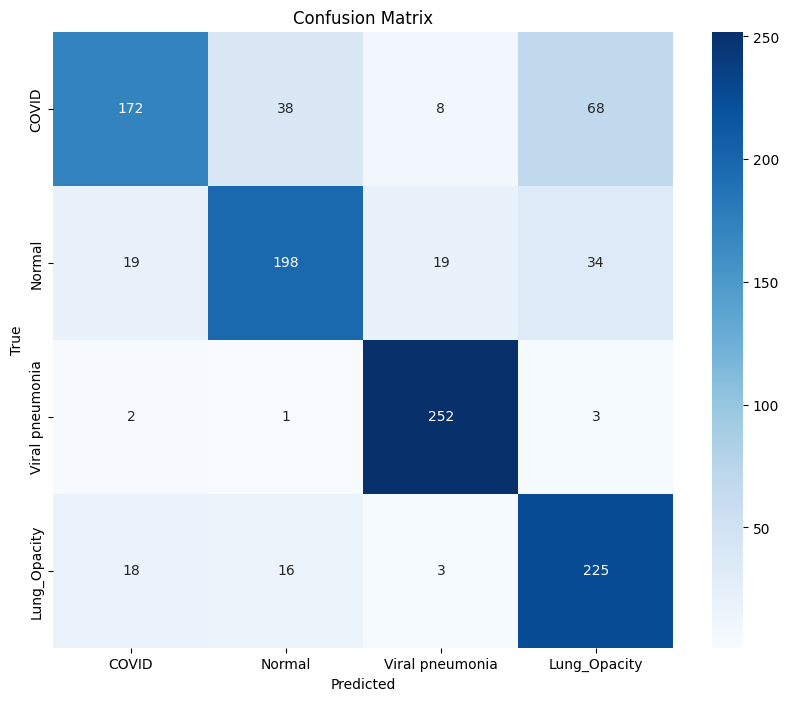

In [49]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, dataloader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    num_classes = len(class_names)

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Class-wise metrics
    precision_per_class, recall_per_class, f1_per_class, _ = precision_recall_fscore_support(all_labels, all_preds, labels=np.arange(num_classes))

    for i, class_name in enumerate(class_names):
        print(f"{class_name} -> Precision: {precision_per_class[i]:.4f}, Recall: {recall_per_class[i]:.4f}, F1: {f1_per_class[i]:.4f}")

    # Overall metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

    print(f"\nOverall Accuracy: {accuracy:.4f}")
    print(f"Overall Precision: {precision:.4f}")
    print(f"Overall Recall: {recall:.4f}")
    print(f"Overall F1-score: {f1:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))
    
    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return accuracy, precision, recall, f1, conf_matrix

# Usage example
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['COVID', 'Normal', 'Viral pneumonia', 'Lung_Opacity']  # Replace with your actual class names
accuracy, precision, recall, f1, conf_matrix = evaluate_model(model, test_loader, device, class_names)